<h3>Технологии машинного обучения, РК1</h3>


Выполнил: Носков А. А., гр. ИУ5-62Б  
Вариант №13 (задача 2, датасет 5)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

sns.set_style("whitegrid")
%matplotlib inline

np.random.seed(42)

In [2]:
df = pd.read_csv('Admission_Predict.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [7]:
print(df.shape)
df.describe()

(400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.2 KB


Видим, что пропусков в данных нет.  
Создадим их искусственно в признаках
- University rating (категориальный)  
- CGPA (числовой)  
  
у 10% сэмплов:

In [12]:
df_missing = df.copy()

n = len(df_missing)
missing_idx_ur = np.random.choice(df_missing.index, size=int(0.1 * n), replace=False)
missing_idx_cgpa = np.random.choice(df_missing.index, size=int(0.1 * n), replace=False)

df_missing.loc[missing_idx_ur, 'University Rating'] = np.nan
df_missing.loc[missing_idx_cgpa, 'CGPA'] = np.nan

print("Пропуски:")
print(df_missing[['University Rating', 'CGPA']].isnull().sum())

Пропуски:
University Rating    40
CGPA                 40
dtype: int64


Посмотрим на исходные распределения:

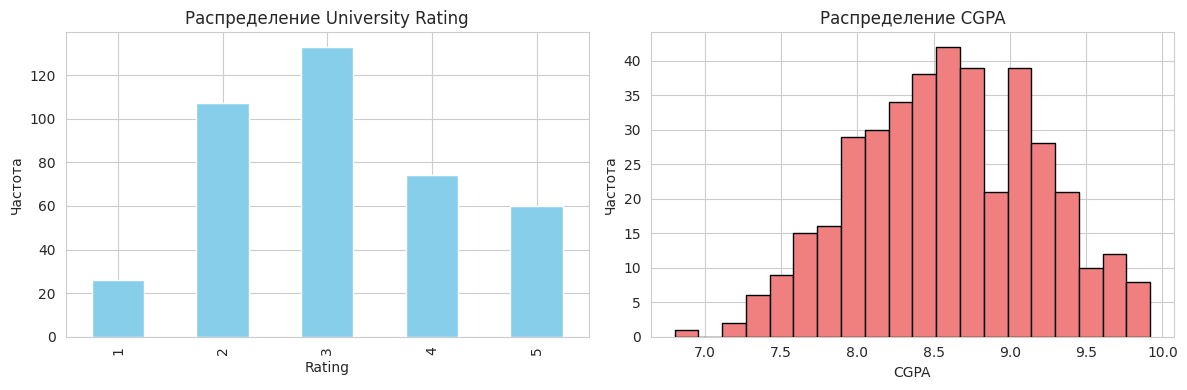

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# University Rating
df['University Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Распределение University Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Частота')

# CGPA
axes[1].hist(df['CGPA'].dropna(), bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Распределение CGPA')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Обработаем пропуски категориального признака University rating:

In [21]:
# создадим копии для разных методов
df_cat_method1 = df_missing.copy()  # метод даления сэмплов
df_cat_method2 = df_missing.copy()  # замена модой
df_cat_method3 = df_missing.copy()  # замена категорией 'Unknown'

# 1. удаление сэмплов
df_cat_method1.dropna(subset=['University Rating'], inplace=True)

# 2. замена модой
mode_val = df['University Rating'].mode()[0]
df_cat_method2['University Rating'] = df_cat_method2['University Rating'].fillna(mode_val)

# 3. замена категорией 'Unknown'
df_cat_method3['University Rating'] = df_cat_method3['University Rating'].fillna('Unknown')

Сравним распределения признака после замены пропусков:

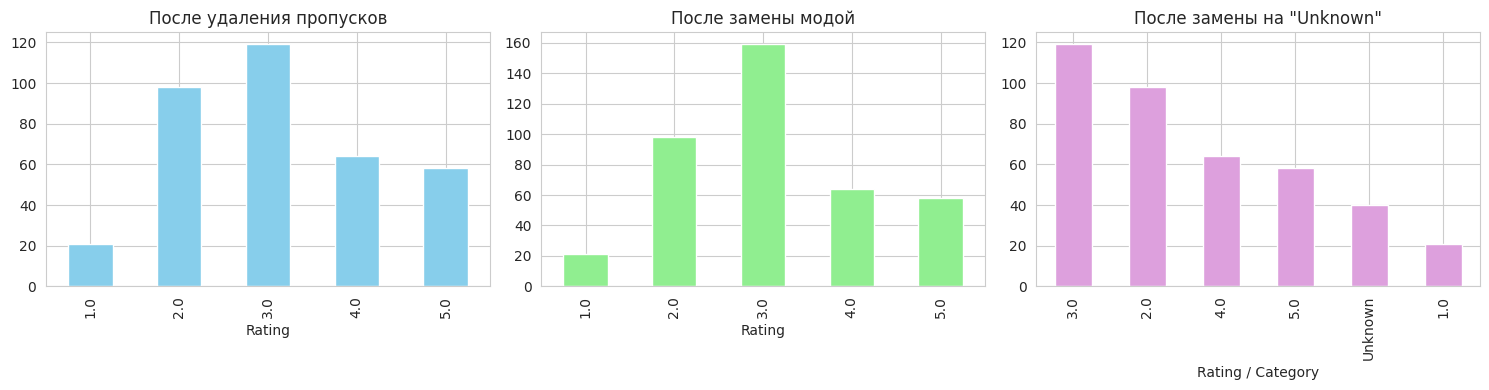

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_cat_method1['University Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('После удаления пропусков')
axes[0].set_xlabel('Rating')

# График 2: замена модой
df_cat_method2['University Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('После замены модой')
axes[1].set_xlabel('Rating')

df_cat_method3['University Rating'].value_counts().plot(kind='bar', ax=axes[2], color='plum')
axes[2].set_title('После замены на "Unknown"')
axes[2].set_xlabel('Rating / Category')

plt.tight_layout()
plt.show()

Обработаем пропуски числового признака CGPA:

In [23]:
# Создадим копии
df_num_method1 = df_missing.copy()  # удаление
df_num_method2 = df_missing.copy()  # замена средним
df_num_method3 = df_missing.copy()  # замена медианой
df_num_method4 = df_missing.copy()  # KNN

# 1. удаление сэмплов с пропусками
df_num_method1.dropna(subset=['CGPA'], inplace=True)

# 2. замена средним
mean_cgpa = df['CGPA'].mean()
df_num_method2['CGPA'].fillna(mean_cgpa, inplace=True)

# 3. замена медианой
median_cgpa = df['CGPA'].median()
df_num_method3['CGPA'].fillna(median_cgpa, inplace=True)

# 4. KNN
imputer = KNNImputer(n_neighbors=5)
cols_for_impute = ['GRE Score', 'TOEFL Score', 'CGPA']

temp_data = df_missing[cols_for_impute].copy()
imputed_array = imputer.fit_transform(temp_data)
df_num_method4[cols_for_impute] = imputed_array

/tmp/ipykernel_21576/3087942081.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num_method2['CGPA'].fillna(mean_cgpa, inplace=True)
/tmp/ipykernel_21576/3087942081.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Сравним распределения признака CGPA после замены пропусков:

In [24]:
print("Статистики CGPA после разных методов обработки:")
print("Исходные полные данные:")
print(df['CGPA'].describe(), "\n")

print("Удаление пропусков:")
print(df_num_method1['CGPA'].describe(), "\n")
print("Замена средним:")
print(df_num_method2['CGPA'].describe(), "\n")
print("Замена медианой:")
print(df_num_method3['CGPA'].describe(), "\n")
print("KNN-импутация:")
print(df_num_method4['CGPA'].describe())

Статистики CGPA после разных методов обработки:
Исходные полные данные:
count    400.000000
mean       8.598925
std        0.596317
min        6.800000
25%        8.170000
50%        8.610000
75%        9.062500
max        9.920000
Name: CGPA, dtype: float64 

Удаление пропусков:
count    360.000000
mean       8.606000
std        0.598541
min        6.800000
25%        8.180000
50%        8.640000
75%        9.080000
max        9.920000
Name: CGPA, dtype: float64 

Замена средним:
count    400.000000
mean       8.605293
std        0.567750
min        6.800000
25%        8.237500
50%        8.598925
75%        9.025000
max        9.920000
Name: CGPA, dtype: float64 

Замена медианой:
count    400.000000
mean       8.606400
std        0.567748
min        6.800000
25%        8.237500
50%        8.610000
75%        9.025000
max        9.920000
Name: CGPA, dtype: float64 

KNN-импутация:
count    400.000000
mean       8.594385
std        0.592213
min        6.800000
25%        8.180000
50% 

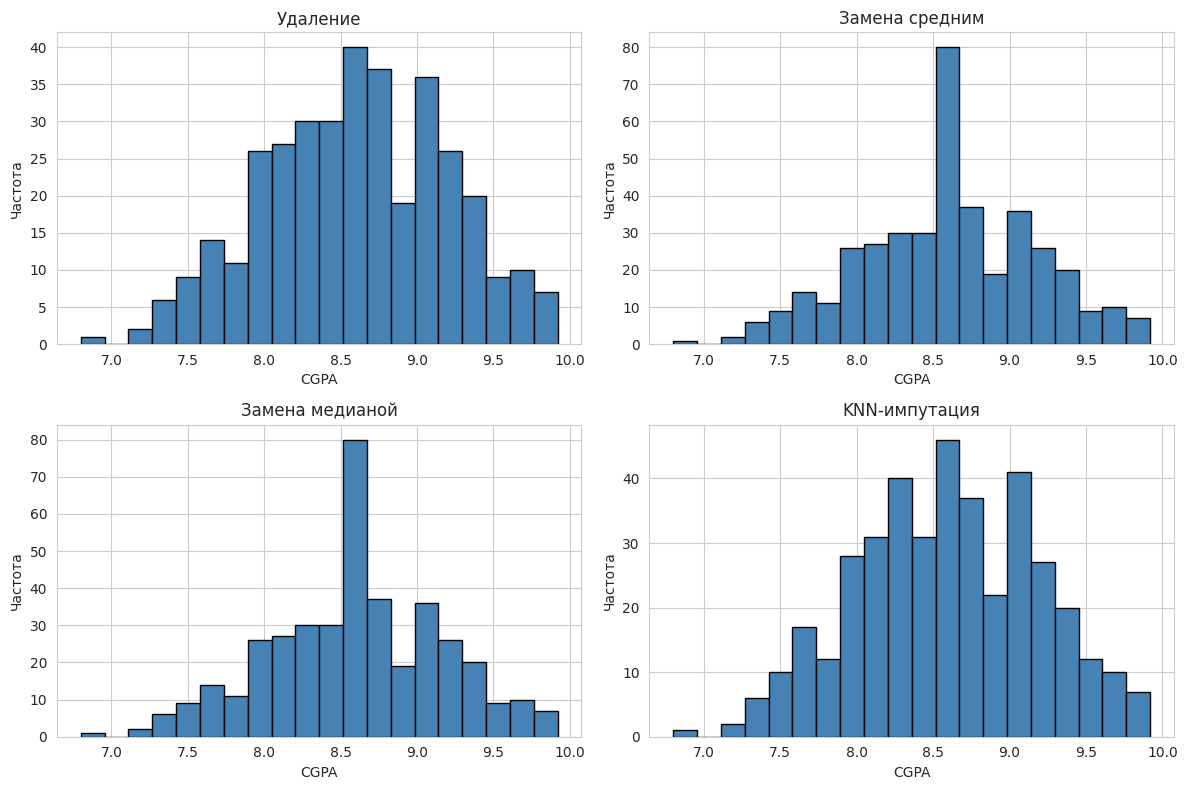

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
methods = [
    (df_num_method1['CGPA'], 'Удаление'),
    (df_num_method2['CGPA'], 'Замена средним'),
    (df_num_method3['CGPA'], 'Замена медианой'),
    (df_num_method4['CGPA'], 'KNN-импутация')
]
for ax, (data, title) in zip(axes.flatten(), methods):
    ax.hist(data.dropna(), bins=20, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('CGPA')
    ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

# Выводы по методам обработки пропусков

Для категориального признака 'University Rating' были применены:
1. Удаление строк – сохраняет исходное распределение, но уменьшает выборку.
2. Замена модой – наиболее частым значением; хорошо, если пропусков немного и распределение не искажается.
3. Замена константой 'Unknown' – создаёт отдельную категорию, что может нести информацию о самом факте пропуска.

Для количественного признака 'CGPA':
1. Удаление строк – теряем данные, но не вносим смещения.
2. Замена средним – просто, но уменьшает дисперсию и искажает распределение при несимметричных данных.
3. Замена медианой – более устойчива к выбросам, чем среднее.
4. KNN-импутация – использует взаимосвязи с другими признаками, может дать более точные оценки, но вычислительно сложнее.

Лучший выбор зависит от доли пропусков и структуры данных. Часто для категориальных признаков используют моду, для количественных – медиану или KNN.
